<a href="https://colab.research.google.com/github/BIRJUNG/-Project--Quora-Duplicate-Question-Detection-with-streamlit/blob/main/%F0%9F%94%8E_Project_Quora_Duplicate_Question_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔎 Quora Duplicate Question Detection  
### 🧠 Industry-Style NLP Pipeline

---

## 📌 Project Overview

Online platforms such as **Quora** receive thousands of questions every day.  
Many users ask the **same question using different wording**, which leads to duplicate content and reduced search efficiency.

This project builds a **Natural Language Processing (NLP) system** that predicts whether two questions are **semantically duplicate** — meaning they express the **same underlying intent** even if the wording differs.

### Example

| Question 1 | Question 2 | Duplicate |
|-------------|-------------|-----------|
| How do I learn Python? | What is the best way to study Python? | ✅ Yes |
| What is machine learning? | How to cook pasta? | ❌ No |

---

## 🎯 Project Objective

The objective of this project is to develop a **machine learning pipeline** capable of:

- Understanding **semantic similarity between questions**
- Converting text into **numerical vector representations**
- Learning patterns that indicate **duplicate intent**
- Predicting whether a new pair of questions is **duplicate or not**

This type of system is commonly used in **search engines, knowledge bases, and Q&A platforms**.

---

## 💼 Business Value

Duplicate-question detection helps platforms:

- 📚 Reduce redundant content  
- 🔎 Improve search results  
- 🧠 Organize knowledge more efficiently  
- 👥 Improve user experience  

From a data science perspective, this problem can be formulated as a **binary classification task** where the model predicts:


In [1]:
!pip install -q sentence-transformers xgboost

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import re
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, auc
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sentence_transformers import SentenceTransformer

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## ⚙️ Project Configuration


---

### 📂 Dataset Requirement

The input dataset should contain the following columns:

| Column | Description |
|------|-------------|
| `question1` | First question in the pair |
| `question2` | Second question in the pair |
| `is_duplicate` | Target label indicating whether the two questions have the same meaning |

---

### 🎯 Target Variable


In [3]:
DATA_PATH = "/content/drive/MyDrive/NLP_ADV_PROJECT/train.csv"
EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"
SAMPLE_SIZE = None        # set e.g. 100000 for faster experimentation
USE_SAMPLE = False        # change to True for smaller fast experiments

In [4]:
df = pd.read_csv(DATA_PATH)

print("Raw shape:", df.shape)
df.head()

Raw shape: (404290, 6)


,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


## 🧹 Data Cleaning

Before building the model, we perform a **basic data cleaning step** to ensure the dataset is suitable for training.

The goal is to **retain only the information necessary for duplicate-question detection** while removing incomplete or invalid records.

---

### 🔍 Cleaning Strategy

The following steps are applied to the dataset:

1️⃣ **Keep only relevant columns**

We retain the columns required for the task:

| Column | Purpose |
|------|---------|
| `question1` | First question in the pair |
| `question2` | Second question in the pair |
| `is_duplicate` | Target label (1 = duplicate, 0 = not duplicate) |

---

2️⃣ **Remove rows with missing values**

Rows containing missing or empty text are removed to ensure the model receives **valid input sentences**.

Missing text can cause issues during:

- Embedding generation  
- Feature engineering  
- Model training  

---

### 🧠 Why We Avoid Heavy Text Preprocessing

In traditional NLP pipelines (e.g., TF-IDF), it is common to apply preprocessing steps such as:

- Stopword removal  
- Stemming  
- Lemmatization  

However, in this project we use **SentenceTransformer embeddings**, which are designed to work best with **natural language sentences**.

Therefore, we **avoid aggressive preprocessing** because it can remove useful semantic information.




In [5]:
required_cols = ["question1", "question2", "is_duplicate"]
df = df[required_cols].copy()

print("Before null removal:", df.shape)
df = df.dropna(subset=["question1", "question2", "is_duplicate"]).copy()
print("After null removal:", df.shape)

df["question1"] = df["question1"].astype(str).str.strip()
df["question2"] = df["question2"].astype(str).str.strip()
df["is_duplicate"] = df["is_duplicate"].astype(int)

# remove empty rows after stripping
df = df[(df["question1"] != "") & (df["question2"] != "")].copy()

if USE_SAMPLE and SAMPLE_SIZE is not None:
    df = df.sample(SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)

print("Final cleaned shape:", df.shape)
df.head()

Before null removal: (404290, 3)
After null removal: (404287, 3)
Final cleaned shape: (404287, 3)


,question1,question2,is_duplicate
0,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0



## 📊 Exploratory Data Analysis (EDA)

Before training any machine learning models, we perform **Exploratory Data Analysis (EDA)** to better understand the dataset and identify patterns that may influence model performance.

EDA helps us:
- Understand the **distribution of the target variable**
- Explore **text characteristics of the questions**
- Identify patterns that may help the model distinguish **duplicate vs non-duplicate questions**

---

### 🔎 Key Aspects Analyzed

**1️⃣ Class Balance**

We first examine the distribution of the target variable `is_duplicate` to understand whether the dataset is **balanced or imbalanced**.

Target interpretation:



1 → Duplicate questions
0 → Non-duplicate questions



Understanding class balance is important because **strong imbalance can bias the model toward the majority class** and affect evaluation metrics.

---

**2️⃣ Question Length Distribution**

Next, we analyze the **length of questions** (in characters or word counts) to understand how users typically phrase their questions.

This analysis helps reveal patterns such as:

- Are duplicate questions generally **shorter or longer**?
- Do longer questions provide **more contextual information**?
- Does question length vary significantly across the dataset?



**3️⃣ Length Difference vs Duplicate Likelihood**

We also examine the **difference in length between the two questions in a pair**.

Example:

Question 1: *How can I learn Python?*  
Question 2: *What is the best way to learn Python programming quickly?*

Even though the **sentence lengths differ**, the **semantic intent is similar**.

Analyzing this relationship helps determine whether **length-based features** may improve model performance during feature engineering.



📌 Insights from EDA guide later stages of the pipeline, including **feature engineering, model selection, and evaluation strategy**.



In [6]:
def safe_word_count(text):
    return len(str(text).split())

def safe_char_count(text):
    return len(str(text))

df["q1_word_count"] = df["question1"].apply(safe_word_count)
df["q2_word_count"] = df["question2"].apply(safe_word_count)
df["q1_char_count"] = df["question1"].apply(safe_char_count)
df["q2_char_count"] = df["question2"].apply(safe_char_count)

df["word_count_diff"] = (df["q1_word_count"] - df["q2_word_count"]).abs()
df["char_count_diff"] = (df["q1_char_count"] - df["q2_char_count"]).abs()

df[["q1_word_count", "q2_word_count", "word_count_diff", "is_duplicate"]].head()

,q1_word_count,q2_word_count,word_count_diff,is_duplicate
0,14,12,2,0
1,8,13,5,0
2,14,10,4,0
3,11,9,2,0
4,13,7,6,0


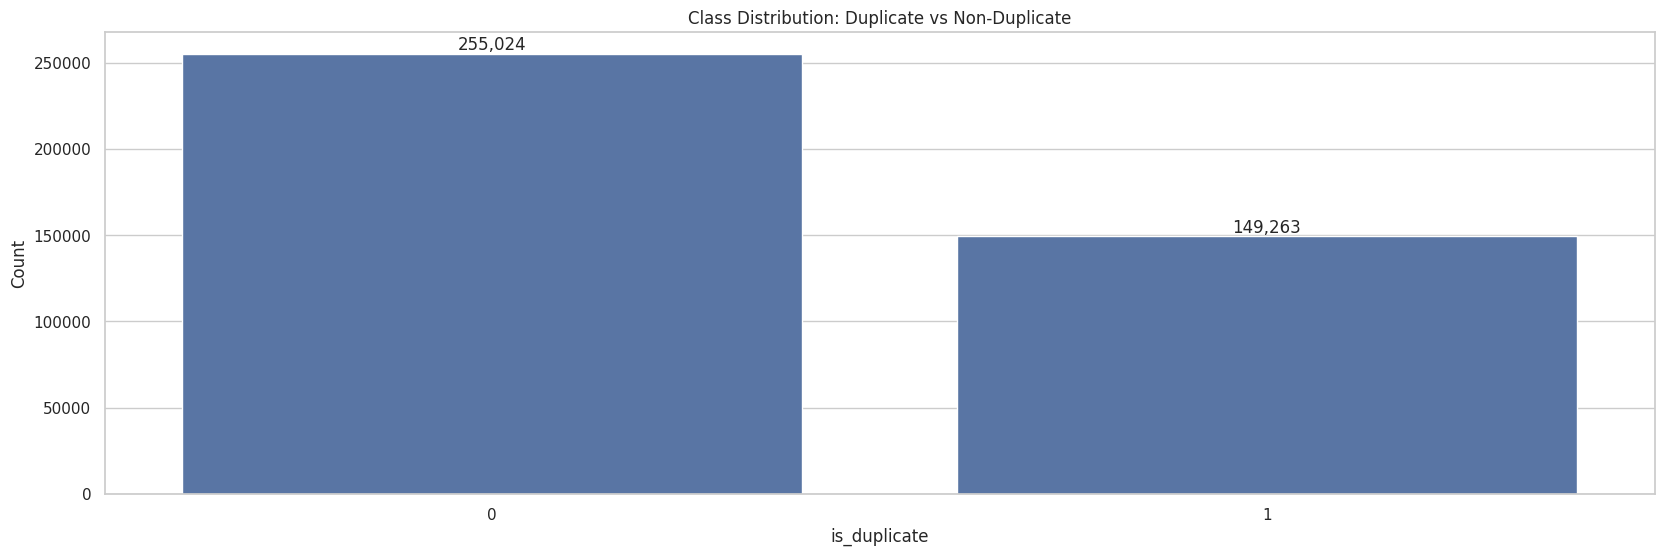

Duplicate rate: 36.92%


In [7]:
plt.figure(figsize=(20, 6))
ax = sns.countplot(data=df, x="is_duplicate")
plt.title("Class Distribution: Duplicate vs Non-Duplicate")
plt.xlabel("is_duplicate")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom"
    )

plt.show()

dup_rate = df["is_duplicate"].mean()
print(f"Duplicate rate: {dup_rate:.2%}")

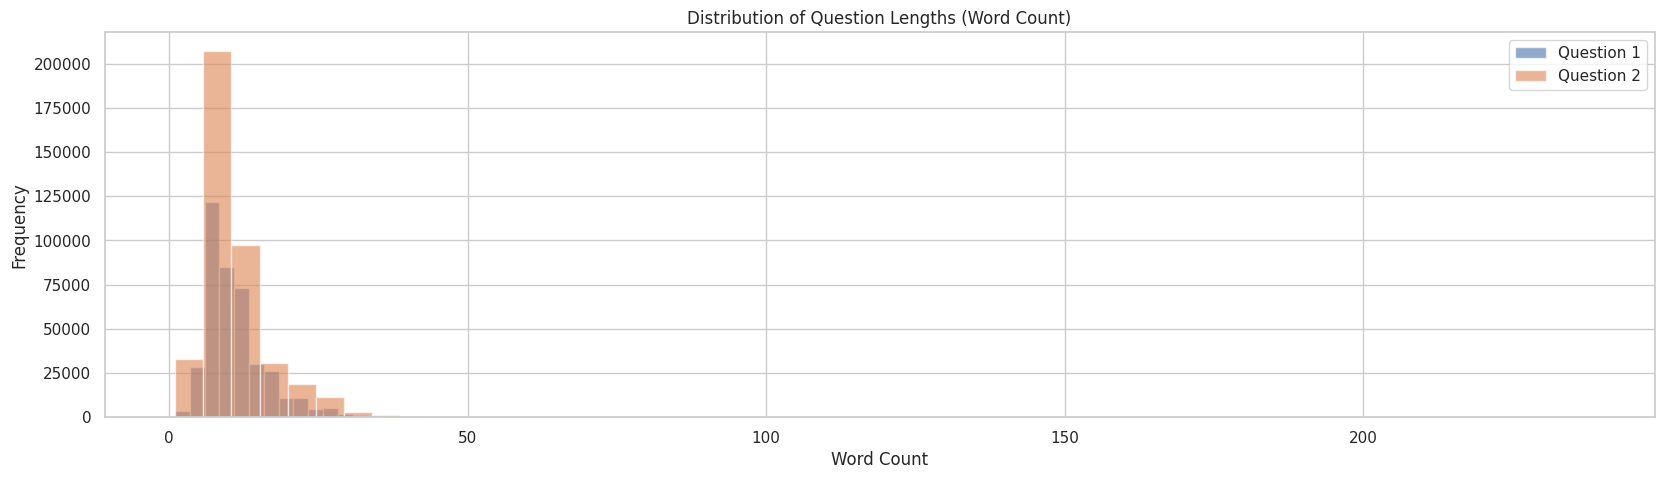

In [8]:
plt.figure(figsize=(20, 5))
plt.hist(df["q1_word_count"], bins=50, alpha=0.6, label="Question 1")
plt.hist(df["q2_word_count"], bins=50, alpha=0.6, label="Question 2")
plt.title("Distribution of Question Lengths (Word Count)")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()
plt.show()

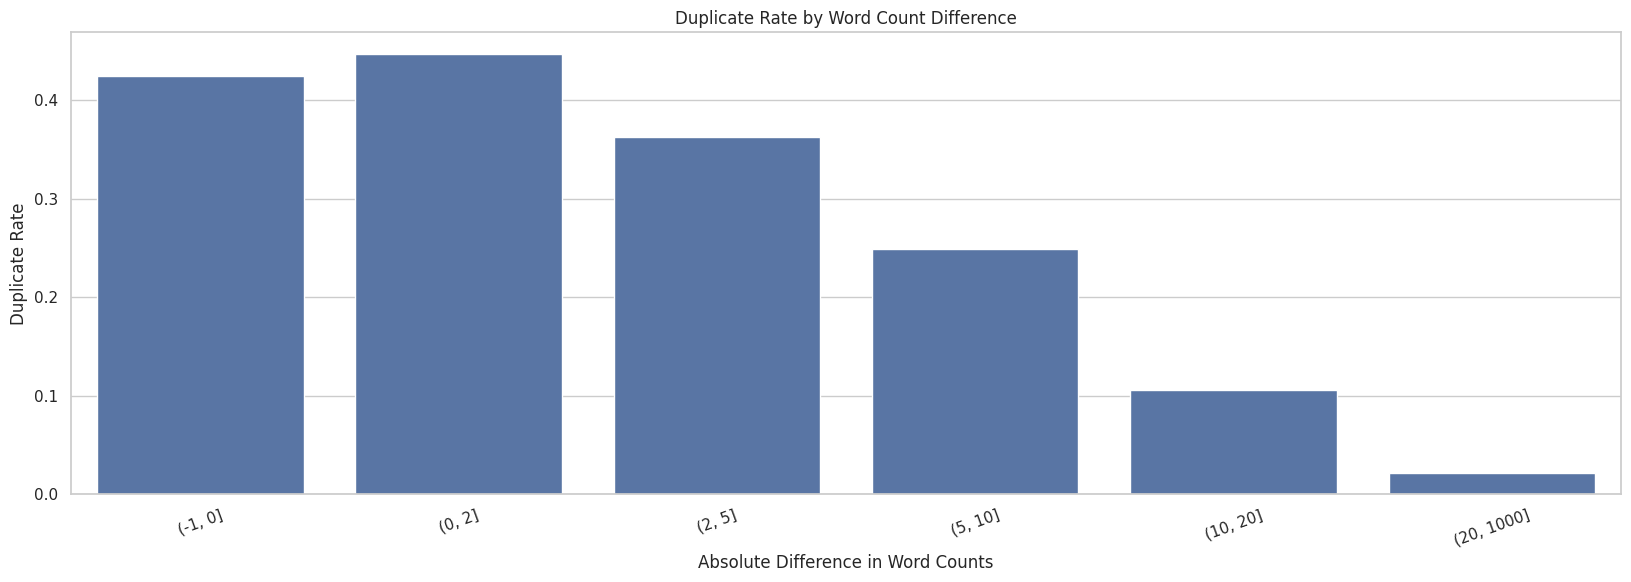

In [9]:
length_bins = pd.cut(df["word_count_diff"], bins=[-1, 0, 2, 5, 10, 20, 1000])
dup_by_len = df.groupby(length_bins)["is_duplicate"].mean().reset_index()

plt.figure(figsize=(20 ,6))
sns.barplot(data=dup_by_len, x="word_count_diff", y="is_duplicate")
plt.title("Duplicate Rate by Word Count Difference")
plt.xlabel("Absolute Difference in Word Counts")
plt.ylabel("Duplicate Rate")
plt.xticks(rotation=20)
plt.show()


## 🧰 Helper Functions

To keep the notebook **clean, modular, and easy to maintain**, we define a set of **utility (helper) functions** that will be reused throughout the machine learning pipeline.

These functions handle common operations such as **text normalization, lexical comparison, vector similarity, and model evaluation**, ensuring the workflow remains **organized and consistent**.

---

### 🔧 Utility Functions Included

**1️⃣ Text Normalization**

This function prepares text before computing **lexical similarity features**.

Typical normalization steps include:
- Converting text to **lowercase**
- Removing **extra whitespace**
- Ensuring consistent formatting across questions

Example:

Original text  


How Do I Learn PYTHON?


Normalized text  

how do i learn python


Normalization ensures that tokens like **Python**, **python**, and **PYTHON** are treated as the same word.

---

**2️⃣ Token Overlap Computation**

This function measures the number of **shared tokens (words)** between two questions.

Example:



Question 1: How to learn Python
Question 2: Best way to learn Python


Shared tokens → `learn`, `python`

Token overlap provides a **simple lexical similarity signal** that complements semantic embeddings.

---

**3️⃣ Cosine Similarity**

Cosine similarity measures the **angle between two vectors in high-dimensional space**.

In this project, it compares the **SentenceTransformer embeddings** of `question1` and `question2`.

Interpretation:


Cosine Similarity ≈ 1.0 → Very similar questions
Cosine Similarity ≈ 0.0 → Unrelated questions



This feature captures **semantic similarity between sentences**.

---

**4️⃣ Metric Reporting**

Helper functions are also defined to report **model evaluation metrics** consistently across experiments.

Common metrics include:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

These metrics help compare models objectively and select the **best-performing model for deployment**.

---

📌 Defining helper functions improves **code readability, reusability, and maintainability**, which is a common practice in **industry-level machine learning pipelines**.



In [10]:
#Helper Functions Code Cell
def normalize_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def token_set(text):
    return set(normalize_text(text).split())

def jaccard_similarity(q1, q2):
    s1 = token_set(q1)
    s2 = token_set(q2)
    if len(s1.union(s2)) == 0:
        return 0.0
    return len(s1.intersection(s2)) / len(s1.union(s2))

def token_overlap_ratio(q1, q2):
    s1 = token_set(q1)
    s2 = token_set(q2)
    denom = min(len(s1), len(s2))
    if denom == 0:
        return 0.0
    return len(s1.intersection(s2)) / denom

def cosine_similarity_matrix(a, b):
    a_norm = a / np.clip(np.linalg.norm(a, axis=1, keepdims=True), 1e-12, None)
    b_norm = b / np.clip(np.linalg.norm(b, axis=1, keepdims=True), 1e-12, None)
    return np.sum(a_norm * b_norm, axis=1)

def evaluate_at_threshold(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }

def print_metrics(title, y_true, y_prob, threshold=0.5):
    metrics = evaluate_at_threshold(y_true, y_prob, threshold)
    print(f"\n{title}")
    print("-" * len(title))
    for k, v in metrics.items():
        if k == "threshold":
            print(f"{k:10s}: {v:.3f}")
        else:
            print(f"{k:10s}: {v:.4f}")

In [11]:
#Split Data
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["is_duplicate"],
    random_state=RANDOM_STATE
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    stratify=train_df["is_duplicate"],
    random_state=RANDOM_STATE
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nClass ratio check")
print("Train duplicate rate:", round(train_df["is_duplicate"].mean(), 4))
print("Val duplicate rate  :", round(val_df["is_duplicate"].mean(), 4))
print("Test duplicate rate :", round(test_df["is_duplicate"].mean(), 4))

Train shape: (258743, 9)
Validation shape: (64686, 9)
Test shape: (80858, 9)

Class ratio check
Train duplicate rate: 0.3692
Val duplicate rate  : 0.3692
Test duplicate rate : 0.3692


## 🧠 Sentence Embeddings

To capture the **semantic meaning of each question**, we convert the text into **dense vector representations (embeddings)** using a transformer-based model.

In this project, we use the **SentenceTransformer model**:

`all-MiniLM-L6-v2`

This model is widely used for **semantic similarity tasks** because it produces high-quality embeddings while remaining **computationally efficient**.

⚙️ Embedding Strategy

Each question is encoded **separately**:

- `question1 → embedding vector`
- `question2 → embedding vector`

These embeddings represent the **semantic meaning of each sentence in a high-dimensional vector space**.

📌 Why Separate Encoding is Important

Duplicate-question detection is fundamentally a **pairwise semantic task**, meaning the goal is to determine the relationship between **two independent sentences**.

Encoding questions separately provides several advantages:

- Each question receives its **own semantic representation**
- The model captures the **individual meaning of each sentence**
- We can compute **relationship-based features between the two embeddings**

🔗 Relationship-Aware Features

Once embeddings are generated, we construct features that describe how the two questions relate to each other.

Examples include:

- Cosine similarity between embeddings  
- Absolute embedding difference
- Element-wise embedding product

These features allow the model to learn patterns that indicate whether two questions **share the same intent**.



In [12]:
#loading sentence Transformer
embedder = SentenceTransformer(EMBEDDING_MODEL_NAME)
embedder

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)

In [13]:
#Encode Questions
def encode_questions(series, model, batch_size=128, show_progress_bar=True):
    return model.encode(
        series.tolist(),
        batch_size=batch_size,
        show_progress_bar=show_progress_bar,
        convert_to_numpy=True
    )

print("Encoding train question1...")
train_q1_emb = encode_questions(train_df["question1"], embedder)

print("Encoding train question2...")
train_q2_emb = encode_questions(train_df["question2"], embedder)

print("Encoding validation question1...")
val_q1_emb = encode_questions(val_df["question1"], embedder)

print("Encoding validation question2...")
val_q2_emb = encode_questions(val_df["question2"], embedder)

print("Encoding test question1...")
test_q1_emb = encode_questions(test_df["question1"], embedder)

print("Encoding test question2...")
test_q2_emb = encode_questions(test_df["question2"], embedder)

print("Embedding shape:", train_q1_emb.shape)

Encoding train question1...


Batches:   0%|          | 0/2022 [00:00<?, ?it/s]

Encoding train question2...


Batches:   0%|          | 0/2022 [00:00<?, ?it/s]

Encoding validation question1...


...

Encoding test question1...


Batches:   0%|          | 0/632 [00:00<?, ?it/s]

Encoding test question2...


Batches:   0%|          | 0/632 [00:00<?, ?it/s]

Embedding shape: (258743, 384)


## 🧩 Pairwise Feature Engineering

After generating embeddings for `question1` and `question2`, we create **pairwise features** that describe how the two questions relate to each other.  
The goal is to combine **semantic signals (meaning)** with **lexical/structural signals (surface text patterns)** so the classifier can better detect duplicate questions.



### 🧠 Semantic Features

These features are derived from the **SentenceTransformer embeddings** and capture the **meaning-level relationship** between the two questions.

- **Cosine Similarity**  
  Measures how close the two embedding vectors are in semantic space.

  `cosine_similarity(e1, e2)`

  Values closer to **1** indicate very similar questions, while values near **0** indicate unrelated sentences.

- **Absolute Embedding Difference**  
  Captures the distance between the two semantic vectors.

  `|e1 - e2|`

  This helps the model learn **how far apart the meanings of the two questions are**.

- **Element-wise Interaction**  
  Captures interactions between corresponding embedding dimensions.

  `e1 * e2`

  This allows the classifier to learn **dimension-wise relationships between embeddings**.



### 📝 Lexical / Structural Features

These features capture **surface-level similarities in the text**.

- **Word Count Difference**  
  Difference in the number of words between the two questions.

- **Character Count Difference**  
  Measures how different the questions are in terms of **text length**.

- **Jaccard Similarity**  
  Compares the overlap between token sets.

  `Jaccard = |intersection(tokens)| / |union(tokens)|`

- **Token Overlap Ratio**  
  Measures the proportion of **shared words** between the two questions.

Example:
Q1: How to learn Python
Q2: Best way to learn Python


Shared tokens → `learn`, `python`


🎯 Why Combine These Features?

Using both feature types helps the model capture **multiple dimensions of similarity**:

- **Semantic features → meaning-level similarity**
- **Lexical features → surface-level text similarity**

This combination allows the classifier to detect **duplicate questions even when wording differs significantly**, which is essential for real-world NLP systems.

In [14]:
#Building Feature Functions
def build_pair_features(frame, q1_emb, q2_emb):
    cosine_sim = cosine_similarity_matrix(q1_emb, q2_emb).reshape(-1, 1)
    abs_diff = np.abs(q1_emb - q2_emb)
    prod = q1_emb * q2_emb

    lexical_features = pd.DataFrame({
        "q1_word_count": frame["question1"].apply(safe_word_count).values,
        "q2_word_count": frame["question2"].apply(safe_word_count).values,
        "q1_char_count": frame["question1"].apply(safe_char_count).values,
        "q2_char_count": frame["question2"].apply(safe_char_count).values,
        "word_count_diff": (frame["question1"].apply(safe_word_count).values - frame["question2"].apply(safe_word_count).values).astype(float),
        "char_count_diff": (frame["question1"].apply(safe_char_count).values - frame["question2"].apply(safe_char_count).values).astype(float),
        "jaccard_similarity": [jaccard_similarity(a, b) for a, b in zip(frame["question1"], frame["question2"])],
        "token_overlap_ratio": [token_overlap_ratio(a, b) for a, b in zip(frame["question1"], frame["question2"])]
    })

    lexical_array = lexical_features.values.astype(float)

    X = np.hstack([
        cosine_sim,
        lexical_array,
        abs_diff,
        prod
    ])

    feature_summary = {
        "cosine_dim": cosine_sim.shape[1],
        "lexical_dim": lexical_array.shape[1],
        "abs_diff_dim": abs_diff.shape[1],
        "prod_dim": prod.shape[1],
        "total_dim": X.shape[1]
    }

    return X, lexical_features, feature_summary

In [15]:
# Creating Final Matrices
X_train, train_lexical, feature_summary = build_pair_features(train_df, train_q1_emb, train_q2_emb)
X_val, val_lexical, _ = build_pair_features(val_df, val_q1_emb, val_q2_emb)
X_test, test_lexical, _ = build_pair_features(test_df, test_q1_emb, test_q2_emb)

y_train = train_df["is_duplicate"].values
y_val = val_df["is_duplicate"].values
y_test = test_df["is_duplicate"].values

print("Feature block summary:")
print(feature_summary)

print("\nFinal matrix shapes:")
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

Feature block summary:
{'cosine_dim': 1, 'lexical_dim': 8, 'abs_diff_dim': 384, 'prod_dim': 384, 'total_dim': 777}

Final matrix shapes:
X_train: (258743, 777)
X_val  : (64686, 777)
X_test : (80858, 777)


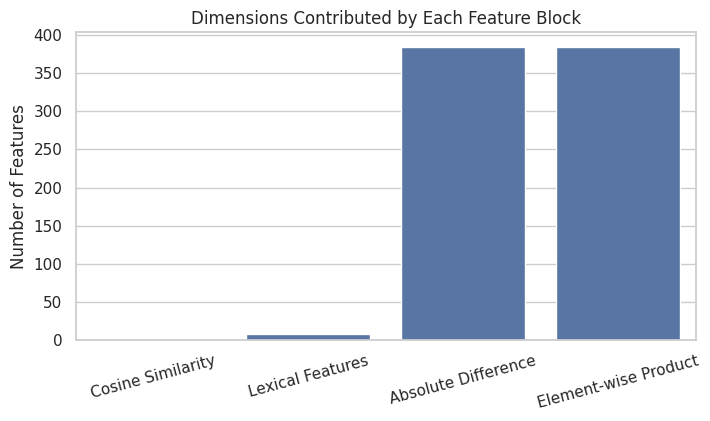

,Feature Block,Dimensions
0,Cosine Similarity,1
1,Lexical Features,8
2,Absolute Difference,384
3,Element-wise Product,384


In [16]:
#Quick Feature Insight Chart
feature_block_df = pd.DataFrame({
    "Feature Block": ["Cosine Similarity", "Lexical Features", "Absolute Difference", "Element-wise Product"],
    "Dimensions": [
        feature_summary["cosine_dim"],
        feature_summary["lexical_dim"],
        feature_summary["abs_diff_dim"],
        feature_summary["prod_dim"]
    ]
})

plt.figure(figsize=(8, 4))
sns.barplot(data=feature_block_df, x="Feature Block", y="Dimensions")
plt.title("Dimensions Contributed by Each Feature Block")
plt.ylabel("Number of Features")
plt.xlabel("")
plt.xticks(rotation=15)
plt.show()

feature_block_df

## 🤖 Model Benchmarking

To identify the most effective algorithm for duplicate-question detection, we evaluate **multiple machine learning classifiers** using the engineered features.

The models compared in this project are:

- **Logistic Regression**
- **Random Forest**
- **XGBoost**

Each model represents a different **learning paradigm**, allowing us to understand how various algorithms respond to the semantic and lexical features created earlier in the pipeline.



### 📊 Why Benchmark Multiple Models?

Different models capture patterns in data differently. Since our feature set includes **dense semantic embeddings** and **engineered pairwise features**, performance can vary significantly depending on the model type.

- **Logistic Regression**  
  A strong **linear baseline model** that works well when relationships between features and the target variable are mostly linear.

- **Random Forest**  
  A **tree-based ensemble model** capable of capturing **non-linear relationships** and feature interactions.

- **XGBoost**  
  A **gradient boosting algorithm** known for high predictive performance and the ability to model **complex feature interactions**.



### 🎯 Goal of Benchmarking

By comparing multiple models, we can:

- Identify which algorithm performs best on **semantic similarity features**
- Understand whether the problem benefits more from **linear or non-linear models**
- Select the **best-performing model for final evaluation and deployment**

Benchmarking ensures that the final model choice is **data-driven rather than assumption-driven**, which is a common practice in **industry-level machine learning workflows**.

In [17]:
# Validation Comparison Chart
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

val_results = []

for name, model in models.items():
    print(f"\nTraining: {name}")
    model.fit(X_train, y_train)

    val_prob = model.predict_proba(X_val)[:, 1]
    metrics_05 = evaluate_at_threshold(y_val, val_prob, threshold=0.5)

    row = {
        "model": name,
        "val_accuracy@0.5": metrics_05["accuracy"],
        "val_precision@0.5": metrics_05["precision"],
        "val_recall@0.5": metrics_05["recall"],
        "val_f1@0.5": metrics_05["f1"]
    }
    val_results.append(row)

val_results_df = pd.DataFrame(val_results).sort_values(by="val_f1@0.5", ascending=False)
val_results_df


Training: Logistic Regression

Training: Random Forest

Training: XGBoost


,model,val_accuracy@0.5,val_precision@0.5,val_recall@0.5,val_f1@0.5
2,XGBoost,0.845732,0.776963,0.816556,0.796268
0,Logistic Regression,0.805862,0.687198,0.870321,0.767994
1,Random Forest,0.810948,0.760775,0.711749,0.735446


In [18]:
# Select Best Model
best_model_name = val_results_df.iloc[0]["model"]
best_model = models[best_model_name]

print("Best model based on validation F1 @ 0.50:", best_model_name)

Best model based on validation F1 @ 0.50: XGBoost


## 🎯 Threshold Tuning

In binary classification models, predictions are often converted to class labels using a **default probability threshold of 0.50**.  
However, this default value is **not always optimal** for every problem.

In duplicate-question detection, the choice of threshold affects how the model balances **false positives** and **false negatives**.

### ⚖️ Precision vs Recall Tradeoff

Adjusting the classification threshold allows us to control the balance between two key metrics:

**Precision**  
Measures how many predicted duplicates are actually correct.

High precision helps **avoid false duplicate predictions**, which is important for maintaining content quality.

**Recall**  
Measures how many true duplicate questions the model successfully identifies.

High recall helps ensure that **actual duplicates are not missed**.

### 🔧 Why Threshold Tuning is Important

Different applications require different trade-offs:

- A **higher threshold** increases precision but may reduce recall.
- A **lower threshold** increases recall but may introduce more false positives.

By tuning the threshold, we can find the **best balance between precision and recall** for this task.

### 📌 Validation-Based Tuning

To avoid **data leakage**, threshold tuning is performed **only on the validation dataset**.

Workflow:
1. Train the model on the **training data**
2. Evaluate prediction probabilities on the **validation set**
3. Test multiple thresholds
4. Select the threshold that gives the **best performance balance**
5. Apply the selected threshold to the **final test evaluation**

🚀 This step helps improve the **real-world reliability of the duplicate detection system** by ensuring the model's decision boundary is optimized for the task.

In [19]:
#Thersold Search
val_prob = best_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.02)
threshold_metrics = []

for t in thresholds:
    res = evaluate_at_threshold(y_val, val_prob, threshold=t)
    threshold_metrics.append(res)

threshold_df = pd.DataFrame(threshold_metrics)
threshold_df.head()

,threshold,accuracy,precision,recall,f1
0,0.10,0.733822,0.582150,0.988694,0.732814
1,0.12,0.748168,0.596174,0.985303,0.742865
2,0.14,0.760134,0.608621,0.981409,0.751314
3,0.16,0.770615,0.620106,0.977598,0.758857
4,0.18,0.780509,0.631712,0.972406,0.765880


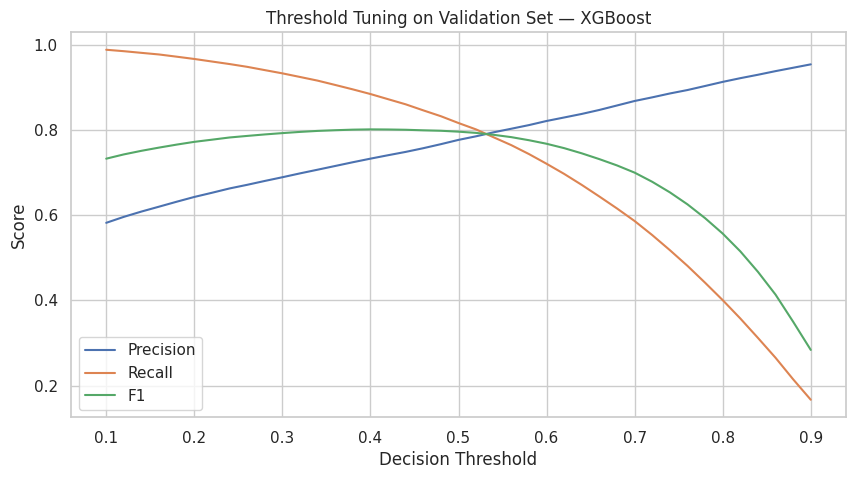

In [20]:
#Thersold Chart
plt.figure(figsize=(10, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.title(f"Threshold Tuning on Validation Set — {best_model_name}")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

In [21]:
# Best Thersold
best_threshold_row = threshold_df.sort_values(by="f1", ascending=False).iloc[0]
best_threshold = float(best_threshold_row["threshold"])

print("Best threshold based on validation F1:", round(best_threshold, 3))
best_threshold_row

Best threshold based on validation F1: 0.4


,15
threshold,0.400000
accuracy,0.838373
precision,0.732873
recall,0.884683
f1,0.801654


In [22]:
#Final Test Evaluation
test_prob = best_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= best_threshold).astype(int)

final_accuracy = accuracy_score(y_test, test_pred)
final_precision = precision_score(y_test, test_pred, zero_division=0)
final_recall = recall_score(y_test, test_pred, zero_division=0)
final_f1 = f1_score(y_test, test_pred, zero_division=0)
final_roc_auc = roc_auc_score(y_test, test_prob)

print("Final Test Metrics")
print("------------------")
print(f"Model        : {best_model_name}")
print(f"Threshold    : {best_threshold:.3f}")
print(f"Accuracy     : {final_accuracy:.4f}")
print(f"Precision    : {final_precision:.4f}")
print(f"Recall       : {final_recall:.4f}")
print(f"F1 Score     : {final_f1:.4f}")
print(f"ROC AUC      : {final_roc_auc:.4f}")

Final Test Metrics
------------------
Model        : XGBoost
Threshold    : 0.400
Accuracy     : 0.8402
Precision    : 0.7347
Recall       : 0.8879
F1 Score     : 0.8041
ROC AUC      : 0.9269


In [23]:
#Classification Report
print(classification_report(y_test, test_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9252    0.8124    0.8651     51005
           1     0.7347    0.8879    0.8041     29853

    accuracy                         0.8402     80858
   macro avg     0.8300    0.8501    0.8346     80858
weighted avg     0.8549    0.8402    0.8426     80858



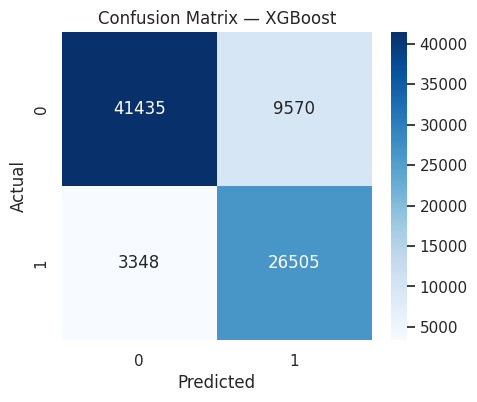

In [24]:
# Confusion Matrix Chart
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

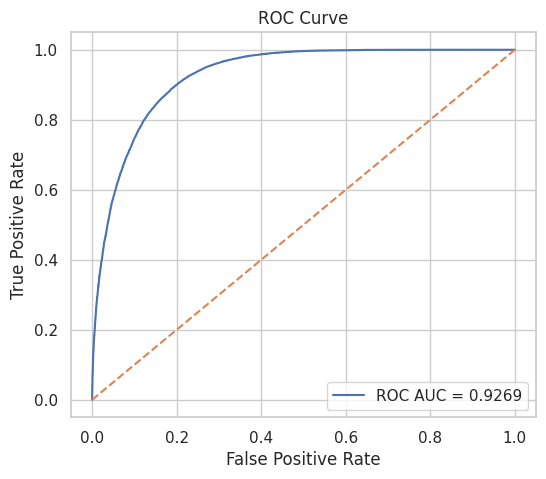

In [25]:
# ROC AUC curve
fpr, tpr, _ = roc_curve(y_test, test_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {final_roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

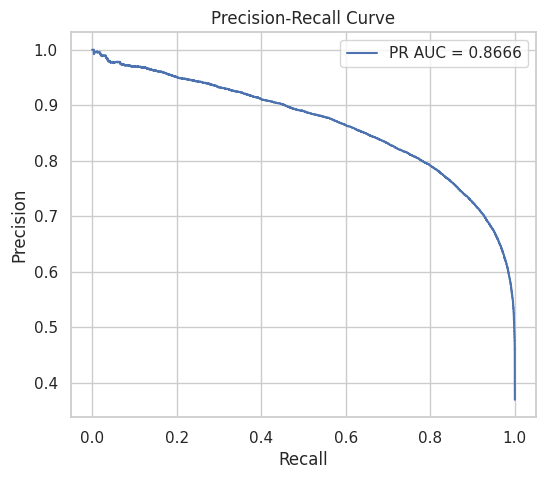

In [26]:
# precision Recall Curve
precisions, recalls, _ = precision_recall_curve(y_test, test_prob)
pr_auc = auc(recalls, precisions)

plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions, label=f"PR AUC = {pr_auc:.4f}")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

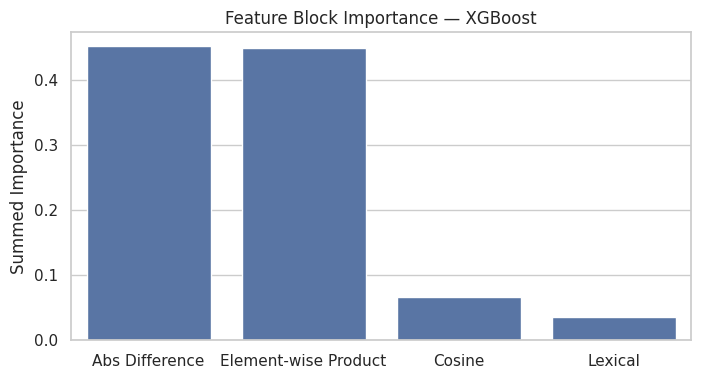

,Feature Block,Importance
2,Abs Difference,0.451211
3,Element-wise Product,0.448766
0,Cosine,0.065578
1,Lexical,0.034445


In [27]:
# Feature Importance for Tree model (optiinal)
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_

    block_sizes = [
        feature_summary["cosine_dim"],
        feature_summary["lexical_dim"],
        feature_summary["abs_diff_dim"],
        feature_summary["prod_dim"]
    ]
    block_names = ["Cosine", "Lexical", "Abs Difference", "Element-wise Product"]

    start = 0
    block_importance = []
    for block_name, size in zip(block_names, block_sizes):
        end = start + size
        block_importance.append(importances[start:end].sum())
        start = end

    block_imp_df = pd.DataFrame({
        "Feature Block": block_names,
        "Importance": block_importance
    }).sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(8, 4))
    sns.barplot(data=block_imp_df, x="Feature Block", y="Importance")
    plt.title(f"Feature Block Importance — {best_model_name}")
    plt.xlabel("")
    plt.ylabel("Summed Importance")
    plt.show()

    display(block_imp_df)
else:
    print("Feature importances not available for this model.")

## 💾 Artifact Saving

After training and evaluation, the final step is to **save the key artifacts required for inference and deployment**.  
Saving these artifacts ensures that the trained pipeline can be **reloaded later without retraining the model**.

### 📦 Artifacts Stored

For production use, we save the following components:

| Artifact | Description |
|--------|-------------|
| **Final Classifier** | The trained machine learning model used to predict duplicate questions |
| **Selected Threshold** | Optimized decision threshold determined during validation |
| **Embedding Model Name** | The SentenceTransformer model used to generate embeddings |
| **Project Metadata** | Additional configuration details for reproducibility |

### 🔧 Why Artifact Saving is Important

Saving artifacts enables:

- **Fast model loading** during inference
- **Reproducible predictions**
- Easy **integration into APIs or production pipelines**
- Separation of **training and deployment environments**

### 📌 Important Note

The **SentenceTransformer model is typically not pickled inside the sklearn model file**.

Instead, in production systems the embedding model is **reloaded by its model name**, for example:

all-MiniLM-L6-v2

This approach keeps the saved model **lightweight, portable, and easier to manage** while ensuring the correct embedding model can be loaded during prediction.

🚀 By saving these artifacts, the project becomes **deployment-ready**, allowing the duplicate-question detection system to be integrated into real-world applications.

In [28]:
# Saving Artifact Coding Blocks
artifact_dir = "artifacts"
os.makedirs(artifact_dir, exist_ok=True)

joblib.dump(best_model, os.path.join(artifact_dir, "quora_duplicate_classifier.joblib"))

metadata = {
    "embedding_model_name": EMBEDDING_MODEL_NAME,
    "best_model_name": best_model_name,
    "best_threshold": best_threshold,
    "feature_summary": feature_summary,
    "test_metrics": {
        "accuracy": final_accuracy,
        "precision": final_precision,
        "recall": final_recall,
        "f1": final_f1,
        "roc_auc": final_roc_auc
    }
}

with open(os.path.join(artifact_dir, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=4)

print("Artifacts saved successfully.")
print(os.listdir(artifact_dir))

Artifacts saved successfully.
['quora_duplicate_classifier.joblib', 'metadata.json']


## 🚀 Deployment Inference Function

After training and saving the model artifacts, the final step is to define an **inference function** that demonstrates how the model would be used in a **real-world application or API**.

This function represents the **production prediction workflow**, where two new questions are provided as input and the system determines whether they are **duplicates or not**.

### ⚙️ Purpose of the Inference Function

The deployment function performs the following operations:

1. Accept **two input questions**
2. Generate **sentence embeddings** using the transformer model
3. Create the required **pairwise features**
4. Apply the **trained classifier**
5. Use the optimized **decision threshold** to produce the final prediction

### 🔄 Typical Inference Pipeline
Input Questions
↓
Sentence Embedding Generation
↓
Feature Engineering
↓
Model Prediction (Probability)
↓
Threshold Decision
↓
Duplicate / Not Duplicate

### 📌 Why This Step Matters

Defining a clear inference function makes it easier to integrate the model into:

- Web applications  
- REST APIs  
- Search systems  
- Question–answer platforms  

It ensures the **same preprocessing, embedding generation, feature construction, and prediction logic** used during training is consistently applied in production.

🚀 This step demonstrates how the trained model can be **deployed to make predictions on new, unseen question pairs in real-world systems**.

In [29]:
# Inference function code cell
def build_single_pair_features(q1, q2, embedder):
    q1_emb = embedder.encode([q1], convert_to_numpy=True)
    q2_emb = embedder.encode([q2], convert_to_numpy=True)

    cosine_sim = cosine_similarity_matrix(q1_emb, q2_emb).reshape(-1, 1)
    abs_diff = np.abs(q1_emb - q2_emb)
    prod = q1_emb * q2_emb

    lexical = np.array([[
        safe_word_count(q1),
        safe_word_count(q2),
        safe_char_count(q1),
        safe_char_count(q2),
        float(safe_word_count(q1) - safe_word_count(q2)),
        float(safe_char_count(q1) - safe_char_count(q2)),
        jaccard_similarity(q1, q2),
        token_overlap_ratio(q1, q2)
    ]])

    X = np.hstack([cosine_sim, lexical, abs_diff, prod])
    return X

def predict_duplicate(q1, q2, embedder, trained_model, threshold):
    X = build_single_pair_features(q1, q2, embedder)
    prob = trained_model.predict_proba(X)[:, 1][0]
    pred = int(prob >= threshold)
    label = "Duplicate" if pred == 1 else "Not Duplicate"

    return {
        "question1": q1,
        "question2": q2,
        "duplicate_probability": round(float(prob), 4),
        "prediction": pred,
        "label": label
    }

In [30]:
#
example_1 = predict_duplicate(
    "How do I learn Python fast?",
    "What is the best way to learn Python quickly?",
    embedder,
    best_model,
    best_threshold
)

example_2 = predict_duplicate(
    "How to bake a chocolate cake?",
    "Why is the sky blue?",
    embedder,
    best_model,
    best_threshold
)

print(example_1)
print(example_2)

{'question1': 'How do I learn Python fast?', 'question2': 'What is the best way to learn Python quickly?', 'duplicate_probability': 0.8774, 'prediction': 1, 'label': 'Duplicate'}
{'question1': 'How to bake a chocolate cake?', 'question2': 'Why is the sky blue?', 'duplicate_probability': 0.0003, 'prediction': 0, 'label': 'Not Duplicate'}
